#### EDA (Exploratory Data Analysis)

1. Load datasets
2. Clean data (missing values,duplicates,types)
3. Treat outliers
4. Univariate and bivariate and multivariate analysis
5. insights

##### Outlier- a data point that is significantly different from other observations in a dataset.

How outliers will come---?
1. Measurement errors
2. Data entry mistakes

Why they are important---?
1. They can be errors
2. They effect the data analysis

How to identify the outliers....?
1. Statistical methods

---> Interquartile Range (IQR)

---> Z-Score

2. Visualization Techniques
---> Box Plots

---> Scatter Plots

---> Histograms


Univariate analysis--a method that analyzes a single variable to describe its characteristics and finding patterns and summarize the data.

It involves only one variable.
 
Bi variate analysis-it will give relationship between 2 variables.It helps to find if there is any co-relation ,association or connection between the 2 variables 

It involves 2 variables (x & y)

Multivariate analysis-To understand how multiple factors interact and influence with each other

It involves more than 2  

Example-

How our age,income,and education level together influence the purchasing behaviour.

### ETL

## EDA : <Dataset>

1. Load &overview

2. Cleaning (missing,dupes,dtypes)

3. Uni , Bi & multi analysis

4. Outlier -IQR

5. Feature Engineering 

6. Key Insights

Feature Engineering - " F.E is the process of turning raw data into useful features" that helps to improve the performance of machine learning models.

1. Load libraries and dataset

In [1]:
import pandas as pd
import numpy as numpy
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load the final dataset from seaborn 
df = pd.read_csv(r"C:\Users\Sriram reddy\Downloads\Final_data.csv")
df.head()
df.tail()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
19995,46.77,Female,98.31,1.90,199.20,148.18,63.72,0.77,761.61,Strength,...,1882.80,0.500000,0.954837,0.623413,0.743876,1865.39,71.269345,533.2558,7.924402e+19,Medium
19996,40.38,Female,88.12,1.87,196.18,134.18,54.04,1.97,2303.13,Strength,...,1205.47,0.496968,0.689060,0.563810,0.683964,173.87,65.049689,1310.6016,5.708474e+19,Low
19997,50.31,Male,46.20,1.67,163.34,157.92,61.65,1.36,1468.80,Strength,...,1947.79,0.500280,2.105844,0.946701,0.966818,-43.80,35.420708,957.9568,9.101285e+19,High
19998,52.36,Male,44.30,1.62,179.27,121.23,60.88,1.41,929.75,Yoga,...,1921.51,0.499940,2.190745,0.509756,0.676243,346.25,35.889260,928.4004,5.246436e+19,Low
19999,29.56,Male,58.63,1.61,198.07,121.74,72.05,1.20,861.84,Yoga,...,1754.55,0.501280,1.494968,0.394302,0.614631,804.16,44.303237,841.1040,8.742467e+19,High


In [3]:
#Basic information and overview of the dataset 
print("Shape of the dataset:",df.shape)
print("\n Info about the dataset ;\n")
df.info()
#Summary Statistics 
df.describe(include='all')

Shape of the dataset: (20000, 54)

 Info about the dataset ;

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)          

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,...,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
count,20000.000000,20000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000,...,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,NaN,Female,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low
freq,NaN,10028,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5003
mean,38.851453,NaN,73.898832,1.723093,179.889702,143.704306,62.195813,1.259446,1280.109600,NaN,...,1998.297076,0.499983,1.460142,0.699005,0.802305,744.308699,53.786384,866.352318,8.631802e+19,NaN
std,12.114580,NaN,21.173010,0.127033,11.510805,14.267688,7.289351,0.341336,502.228982,NaN,...,440.848408,0.001455,0.518946,0.144880,0.096613,720.946619,12.498740,250.317069,3.197579e+19,NaN
min,18.000000,NaN,39.180000,1.490000,159.310000,119.070000,49.490000,0.490000,323.110000,NaN,...,1105.570000,0.492434,0.516706,0.371344,0.599789,-1266.220000,30.946261,219.852800,2.491905e+16,NaN
25%,28.170000,NaN,58.160000,1.620000,170.057500,131.220000,55.960000,1.050000,910.800000,NaN,...,1661.022500,0.499054,1.076294,0.583656,0.727676,261.432500,44.587037,714.098250,6.441978e+19,NaN
50%,39.865000,NaN,70.000000,1.710000,180.140000,142.990000,62.200000,1.270000,1231.450000,NaN,...,1943.130000,0.499981,1.382260,0.686284,0.794834,691.190000,51.204908,868.721400,8.371578e+19,NaN
75%,49.630000,NaN,86.100000,1.800000,189.425000,156.060000,68.090000,1.460000,1553.112500,NaN,...,2271.950000,0.500910,1.750495,0.798196,0.869211,1176.290000,61.939016,1012.532700,1.100442e+20,NaN


In [4]:
#Missing values analysis 

missing=pd.DataFrame({
    'missing_count':df.isnull().sum(),
    'missing_percent':(df.isnull().sum()/ len(df)) * 100
})

missing.sort_values(by='missing_percent',ascending=False)

,missing_count,missing_percent
Age,0,0.0
Gender,0,0.0
Weight (kg),0,0.0
Height (m),0,0.0
Max_BPM,0,0.0
Avg_BPM,0,0.0
Resting_BPM,0,0.0
Session_Duration (hours),0,0.0
Calories_Burned,0,0.0
Workout_Type,0,0.0


In [5]:
# 4. Handling missing values


# Fill numeric missing values with the mean
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

# Fill categorical missing values with the mode
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop 'deck' column only if it exists (safe check)
if 'deck' in df.columns:
    df.drop(columns=['deck'], inplace=True)

# Check remaining missing values
missing_total = df.isnull().sum().sum()
print("✅ Total missing values after cleaning:", missing_total)



✅ Total missing values after cleaning: 0


Insight:We filled important columns and removed highly missing ones.
This keeps maximum information while making the dataset clean.

In [6]:
#Duplicates and data type check

# Count duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

df.drop_duplicates(inplace=True)

# Verify again
print("Duplicates after removal:", df.duplicated().sum())



Number of duplicate rows: 0
Duplicates after removal: 0


Numeric Columns: ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration (hours)', 'Calories_Burned', 'Fat_Percentage', 'Water_Intake (liters)', 'Workout_Frequency (days/week)', 'Experience_Level', 'BMI', 'Daily meals frequency', 'Physical exercise', 'Carbs', 'Proteins', 'Fats', 'Calories', 'sugar_g', 'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'prep_time_min', 'cook_time_min', 'rating', 'Sets', 'Reps', 'Burns Calories (per 30 min)', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg', 'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg', 'expected_burn', 'Burns Calories (per 30 min)_bc']

Summary Statistics for Numeric Features:
                Age   Weight (kg)    Height (m)       Max_BPM       Avg_BPM  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean      38.851453     73.898832      1.723093    179.889702    143.704306   
std       12.114580     21.173010      0.127033     11.510805     14.26768

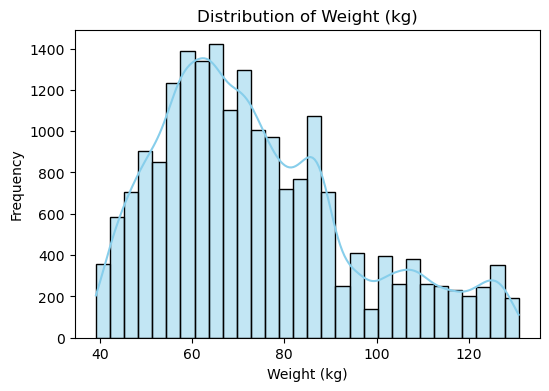

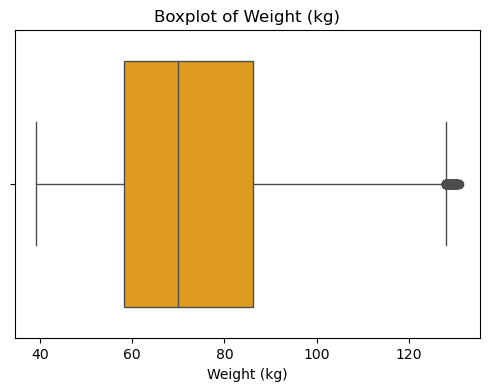

In [7]:
# 6.Univariate analysis -Numerical Features 
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print("Numeric Columns:", num_cols.tolist())

# Summary statistics
print("\nSummary Statistics for Numeric Features:")
print(df[num_cols].describe())

# Plot histograms for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.histplot(df[col], bins=30, kde=True, color='skyblue')
plt.title(f"Distribution of {col}")
plt.xlabel(col)
plt.ylabel("Frequency")
plt.show()

# Plot boxplots for each numeric feature
col=num_cols[1]
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[col], color='orange')
plt.title(f"Boxplot of {col}")
plt.xlabel(col)
plt.show()

Categorical Columns: ['Gender', 'Workout_Type', 'meal_name', 'meal_type', 'diet_type', 'cooking_method', 'Name of Exercise', 'Benefit', 'Target Muscle Group', 'Equipment Needed', 'Difficulty Level', 'Body Part', 'Type of Muscle', 'Workout', 'Burns_Calories_Bin']


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_9536\1971230336.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')


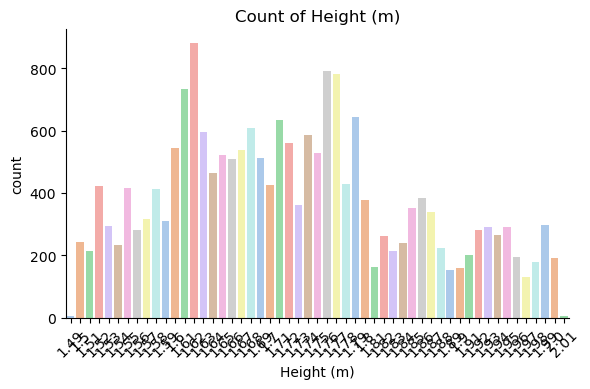

In [9]:
# Univariate Analysis - Categorical Features
# Convert all object columns to category type
df[df.select_dtypes(include=['object']).columns ] = df.select_dtypes(include=['object']).astype('category')

# Identify categorical columns
cat_cols = df.select_dtypes(include='category').columns
print("Categorical Columns:", cat_cols.tolist())

# Plot count plots for each categorical feature
col=num_cols[2]
sns.catplot(x=col, data=df, kind='count', height=4, aspect=1.5, palette='pastel')
plt.title(f"Count of {col}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_9536\3689350428.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weight_bin', y='Height (m)', data=df, palette='Set2')


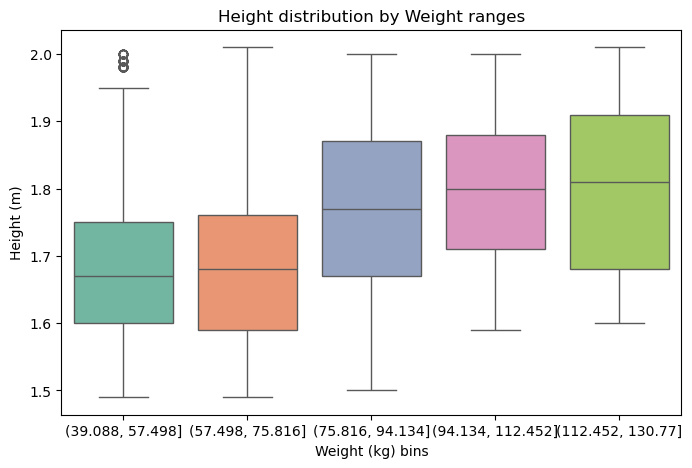

In [13]:
# Bivariate analysis - Numerical vs categorical

df['Weight_bin'] = pd.cut(df['Weight (kg)'], bins=5)  # creates 5 weight ranges

plt.figure(figsize=(8,5))
sns.boxplot(x='Weight_bin', y='Height (m)', data=df, palette='Set2')
plt.title("Height distribution by Weight ranges")
plt.xlabel("Weight (kg) bins")
plt.ylabel("Height (m)")
plt.show()


C:\Users\Sriram reddy\AppData\Local\Temp\ipykernel_9536\4069801926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Age', data=df_under_10, palette='Set2')


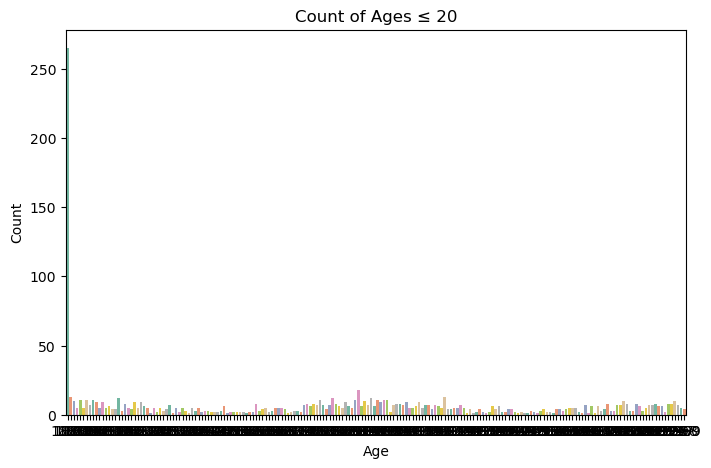

In [ ]:
df_under_10 = df[df['Age'] <= 20]

# Count plot for Age (or any categorical column)
plt.figure(figsize=(8,5))
sns.countplot(x='Age', data=df_under_10, palette='Set2')
plt.title("Count of Ages ≤ 20")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Numeric columns used for correlation (first 5 columns): ['Age', 'Weight (kg)', 'Height (m)', 'Max_BPM', 'Avg_BPM']


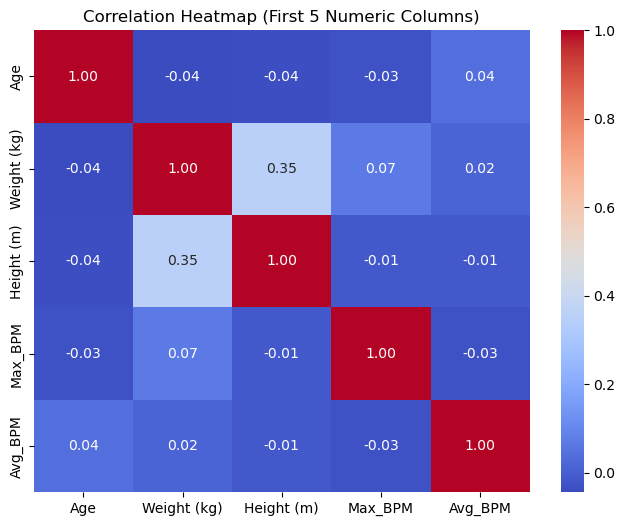

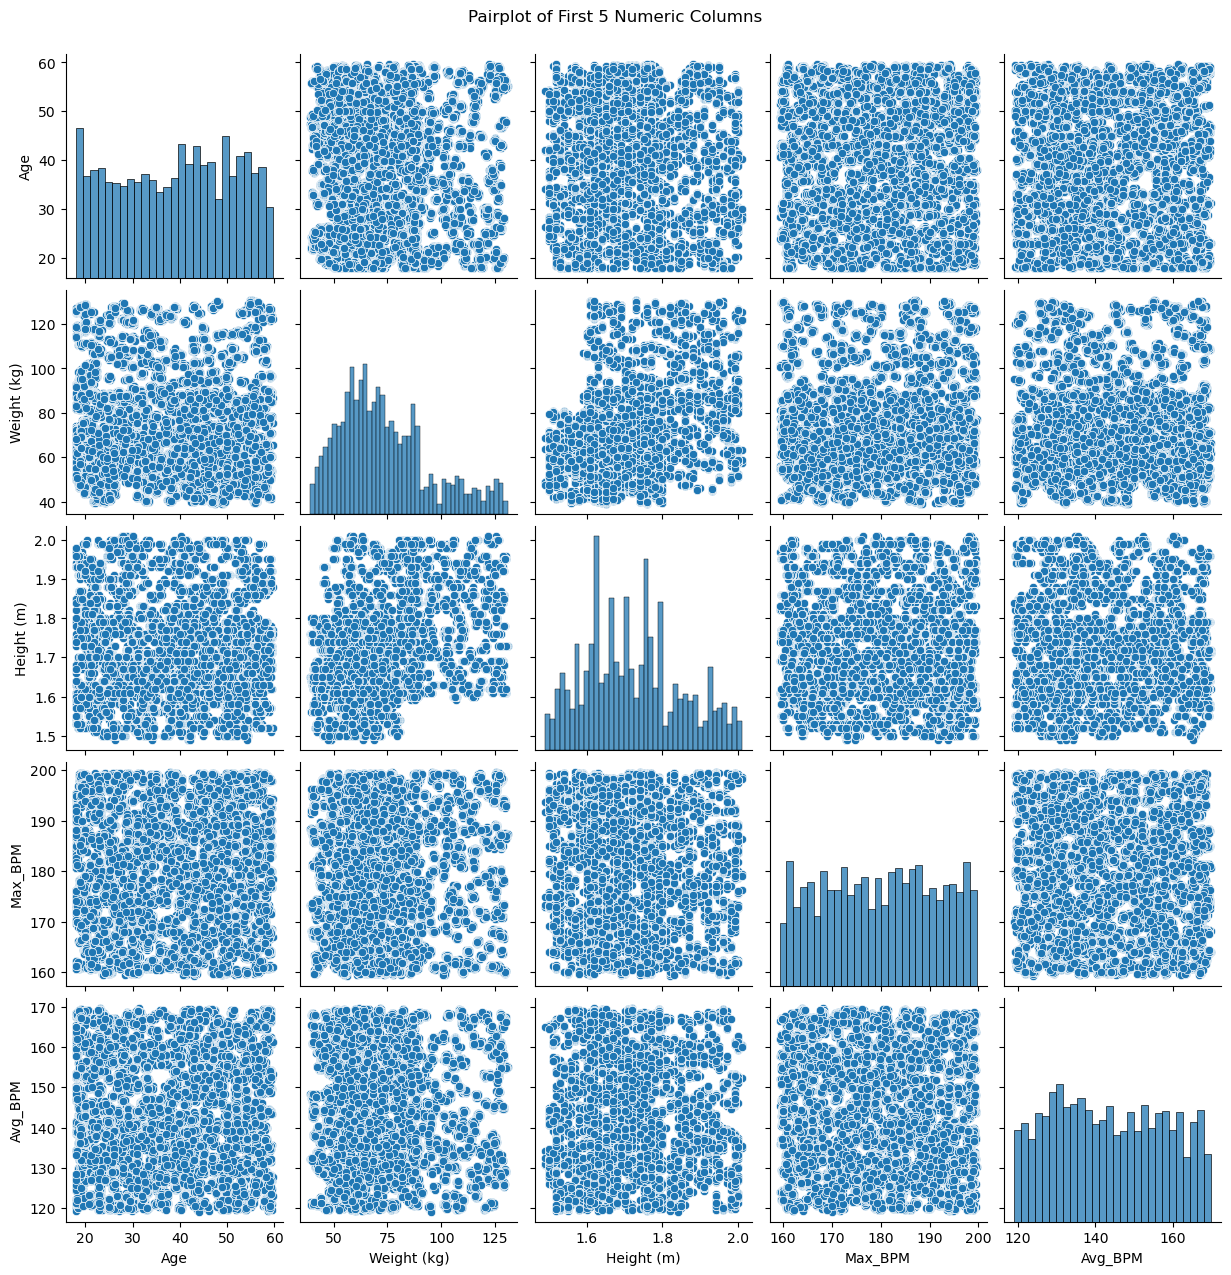

In [22]:
# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Take only the first 5 numeric columns
num_cols_subset = num_cols[:5]
print("Numeric columns used for correlation (first 5 columns):", num_cols_subset.tolist())

# Correlation heatmap
corr = df[num_cols_subset].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (First 5 Numeric Columns)")
plt.show()

# Pairplot for numeric features
sns.pairplot(df[num_cols_subset])
plt.suptitle("Pairplot of First 5 Numeric Columns", y=1.02)
plt.show()

### Insights -

1. Essentially, Age does not show a strong linear relationship with Weight, Height, or BPM metrics.
2. Correlation ≈ 0.35 → moderate positive relationship.

Number of outliers in Age: 0


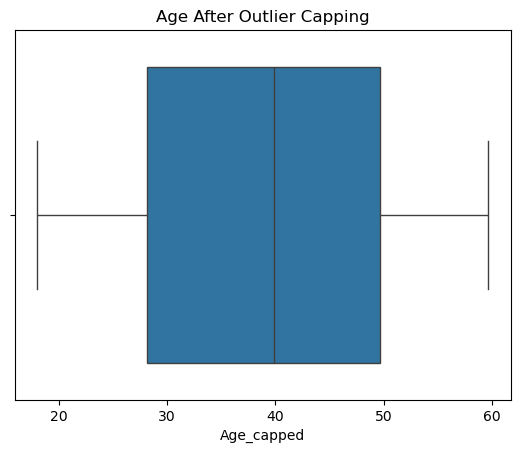

In [32]:
# Outlier Deletion using IQR
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Age'] < lower) | (df['Age'] > upper)]
print("Number of outliers in Age:", len(outliers))

# Capping outliers
df['Age_capped'] = df['Age'].clip(lower, upper)
sns.boxplot(x=df['Age_capped'])
plt.title("Age After Outlier Capping")
plt.show()


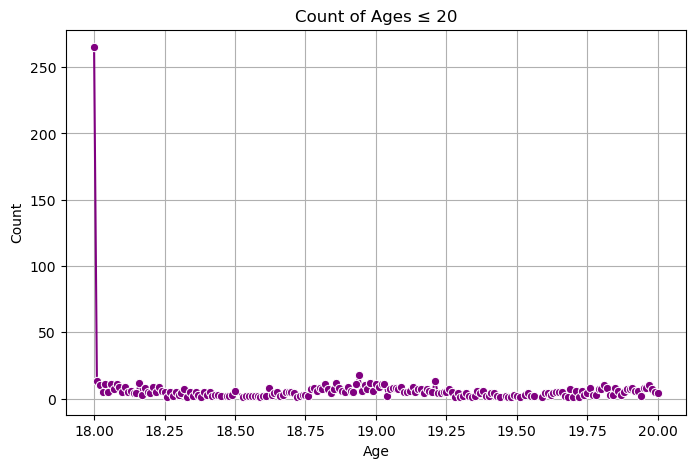

In [27]:
df_under_20 = df[df['Age'] <= 20]

# Count occurrences of each age
age_counts = df_under_20['Age'].value_counts().sort_index().reset_index()
age_counts.columns = ['Age', 'Count']

# Line plot
plt.figure(figsize=(8,5))
sns.lineplot(x='Age', y='Count', data=age_counts, marker='o', color='purple')
plt.title("Count of Ages ≤ 20")
plt.xlabel("Age")
plt.ylabel("Count")
plt.grid(True)
plt.show()

In [31]:
df.to_csv("final_data_cleaned.csv", index=False)
print(f"\n✅ Cleaned fitness data saved as {os.path.abspath('final_data_cleaned.csv')}")



✅ Cleaned fitness data saved as c:\Users\Sriram reddy\OneDrive\Desktop\tekworks\eda assignment\final_data_cleaned.csv


In [30]:
import os
print(os.getcwd())

c:\Users\Sriram reddy\OneDrive\Desktop\tekworks\eda assignment
